<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Classification/Support_Vector_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import libraries

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Import datasets

In [113]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
X = df.iloc[:, 2:-1].values
y = df.iloc[:, -1].values

##Handle missing values

###CHeck for missing values

In [114]:
pd.isna(X).sum(), pd.isnull(y).sum()

(np.int64(0), np.int64(0))

### Handle missing values using SimpleImputer

In [115]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')
X = imputer.fit_transform(X)
np.set_printoptions(suppress = True) ## will not print in scientific format

Reshape the y from 1D array to 2D array

In [116]:
y = y.reshape(-1, 1) ## Reshape the Y to 2D array
y = imputer.fit_transform(y)
y = y.ravel() ## Reshape the y form 2D array to 1D array

##Splitting the dataset into test and train

In [117]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

##Feature Scaling

In [118]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

##Training SVM Model

In [119]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

##Predicting results

In [124]:
y_pred = classifier.predict(X_test)

y_pred_vector = y_pred.reshape(len(y_pred), 1)
y_test_vector = y_test.reshape(len(y_test), 1)

np.concatenate((y_pred_vector, y_test_vector), axis = 1)

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [0., 0.],
       [1., 1.],
       [1., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 1.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 1.

##Confusion matrix

In [126]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[57  1]
 [ 6 16]]


### Heatmap of Confusion matrix

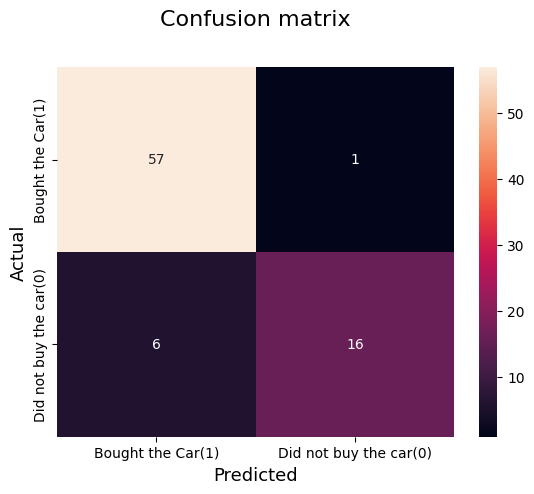

In [142]:
import seaborn as sns
sns.heatmap(cm, annot = True, xticklabels=["Bought the Car(1)", "Did not buy the car(0)"], yticklabels=["Bought the Car(1)", "Did not buy the car(0)"])

plt.title("Confusion matrix", fontsize =16, pad = 30)

plt.ylabel("Actual", fontsize = 13)
plt.xlabel("Predicted", fontsize = 13)

plt.show()

##Accuracy score

In [143]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.9125
